In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install -q transformers torch datasets lime shap requests

import os, json, re, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from collections import defaultdict
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback, pipeline
)
from datasets import Dataset
from lime.lime_text import LimeTextExplainer
import shap
import requests

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.facecolor'] = 'white'

DEVICE     = 0 if torch.cuda.is_available() else -1
MODEL_NAME = 'facebook/roberta-hate-speech-dynabench-r4-target'
LOG_FILE   = 'results_log_west.json'
SEED       = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

results_log = {
    'dataset':    'HateXplain',
    'model_base': MODEL_NAME,
    'timestamp':  datetime.now().isoformat(),
    'experiments': {}
}

def save_log():
    with open(LOG_FILE, 'w') as f:
        json.dump(results_log, f, indent=2)
    print(f'Log saved to {LOG_FILE}')

print(f'Device: {"GPU" if DEVICE == 0 else "CPU"}')
print('Setup complete!')

Device: GPU
Setup complete!


In [ ]:
print('Downloading HateXplain from GitHub...')
url  = 'https://raw.githubusercontent.com/hate-alert/HateXplain/master/Data/dataset.json'
resp = requests.get(url)
raw  = resp.json()

rows = []
for post_id, item in raw.items():
    text   = ' '.join(item['post_tokens'])
    votes  = [a['label'] for a in item['annotators']]
    hate_v = sum(1 for v in votes if v == 'hatespeech')
    label  = 1 if hate_v / len(votes) >= 0.5 else 0
    rows.append({'text': text, 'hate_label': label})

df_all = pd.DataFrame(rows)
print(f'Total samples: {len(df_all)}')
print(df_all['hate_label'].value_counts().rename({0:'Not Hate',1:'Hate'}))

Total samples: 20148
hate_label
Not Hate    14213
Hate         5935
Name: count, dtype: int64


In [ ]:
df_tr_full, df_te = train_test_split(
    df_all, test_size=0.2, random_state=SEED,
    stratify=df_all['hate_label']
)
df_tr, df_val = train_test_split(
    df_tr_full, test_size=0.125, random_state=SEED,
    stratify=df_tr_full['hate_label']
)

print(f'Train : {len(df_tr):>5}  |  Val : {len(df_val):>4}  |  Test : {len(df_te):>5}')
print('\nTest label distribution:')
print(df_te['hate_label'].value_counts().rename({0:'Not Hate',1:'Hate'}))

results_log['data_stats'] = {
    'train': len(df_tr), 'val': len(df_val), 'test': len(df_te),
    'test_hate':     int(df_te['hate_label'].sum()),
    'test_not_hate': int((df_te['hate_label']==0).sum())
}
save_log()

Train : 14103  |  Val : 2015  |  Test :  4030

Test label distribution:
hate_label
Not Hate    2843
Hate        1187
Name: count, dtype: int64
Log saved to results_log_west.json


In [ ]:
print('Loading SOTA classifier...')
zeroshot_pipe = pipeline(
    'text-classification',
    model=MODEL_NAME,
    device=DEVICE,
    batch_size=64
)
print('Model loaded!')

Loading SOTA classifier...


config.json:   0%|          | 0.00/816 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: facebook/roberta-hate-speech-dynabench-r4-target
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded!


In [ ]:
label_map = {'hate': 1, 'nothate': 0}

def run_pipeline(pipe, df):
    raw = pipe(df['text'].tolist(), truncation=True)
    df  = df.copy()
    df['pred_label'] = [label_map[r['label']] for r in raw]
    df['confidence'] = [round(r['score'], 4)   for r in raw]
    return df

def log_metrics(y_true, y_pred, exp_name, split='test'):
    acc         = accuracy_score(y_true, y_pred)
    f1          = f1_score(y_true, y_pred, average='macro')
    prec        = precision_score(y_true, y_pred, average='macro')
    rec         = recall_score(y_true, y_pred, average='macro')
    hate_recall = recall_score(y_true, y_pred, pos_label=1)
    hate_prec   = precision_score(y_true, y_pred, pos_label=1)

    print(f'\n===== {exp_name} | {split} =====')
    print(f'Accuracy      : {acc*100:.2f}%')
    print(f'F1 (macro)    : {f1*100:.2f}%')
    print(f'Hate Recall   : {hate_recall*100:.2f}%')
    print(f'Hate Precision: {hate_prec*100:.2f}%')
    print('\nFull Report:')
    print(classification_report(y_true, y_pred, target_names=['Not Hate','Hate']))

    if exp_name not in results_log['experiments']:
        results_log['experiments'][exp_name] = {}
    results_log['experiments'][exp_name][split] = {
        'accuracy':        round(acc,  4),
        'f1_macro':        round(f1,   4),
        'precision_macro': round(prec, 4),
        'recall_macro':    round(rec,  4),
        'hate_recall':     round(hate_recall, 4),
        'hate_precision':  round(hate_prec,   4),
    }
    save_log()
    return results_log['experiments'][exp_name][split]

df_te_zs  = run_pipeline(zeroshot_pipe, df_te)
zs_metrics = log_metrics(
    df_te_zs['hate_label'], df_te_zs['pred_label'],
    'roberta_west_zeroshot'
)


===== roberta_west_zeroshot | test =====
Accuracy      : 55.51%
F1 (macro)    : 55.51%
Hate Recall   : 94.27%
Hate Precision: 39.35%

Full Report:
              precision    recall  f1-score   support

    Not Hate       0.94      0.39      0.55      2843
        Hate       0.39      0.94      0.56      1187

    accuracy                           0.56      4030
   macro avg       0.67      0.67      0.56      4030
weighted avg       0.78      0.56      0.56      4030

Log saved to results_log_west.json


Running LIME on roberta_west_zeroshot (50 samples, ~4 mins)...
  LIME 0/50...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  LIME 10/50...
  LIME 20/50...
  LIME 30/50...
  LIME 40/50...


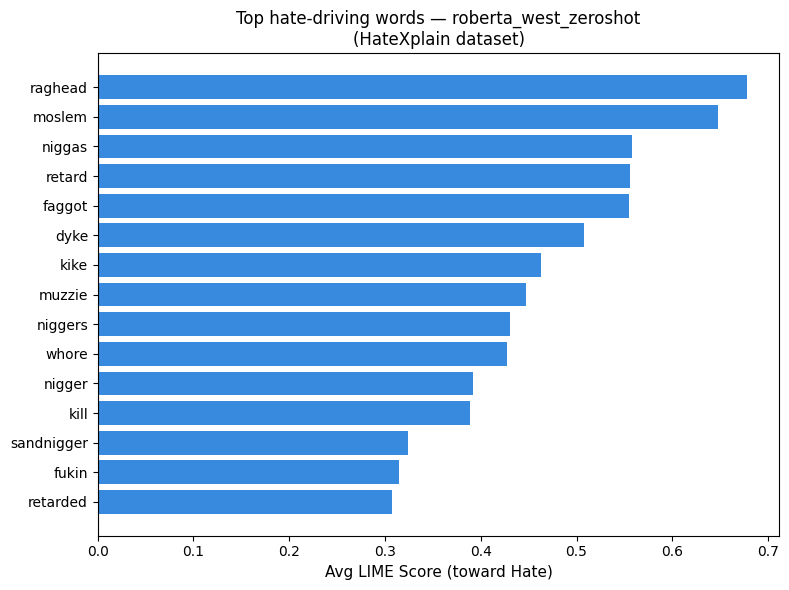

Saved lime_west_zs.png
Log saved to results_log_west.json


In [ ]:
def make_predictor(pipe):
    def predictor(texts):
        results = pipe(texts, truncation=True)
        probs   = []
        for r in results:
            if r['label'] == 'nothate':
                probs.append([r['score'], 1 - r['score']])
            else:
                probs.append([1 - r['score'], r['score']])
        return np.array(probs)
    return predictor

def run_lime(predictor_fn, df, n_samples=50, label='zeroshot', save_prefix='west_zs'):
    explainer   = LimeTextExplainer(class_names=['Not Hate','Hate'])
    hate_df     = df[(df['hate_label']==1) & (df['pred_label']==1)].reset_index(drop=True)
    texts       = hate_df['text'].iloc[:n_samples].tolist()
    word_scores = defaultdict(list)
    for i, text in enumerate(texts):
        if i % 10 == 0: print(f'  LIME {i}/{len(texts)}...')
        exp = explainer.explain_instance(text, predictor_fn, num_features=10, num_samples=300)
        for word, score in exp.as_list():
            word_scores[word].append(score)
    lime_df = pd.DataFrame(
        [(w, np.mean(s)) for w, s in word_scores.items()],
        columns=['word','avg_lime_score']
    ).sort_values('avg_lime_score', ascending=False).reset_index(drop=True)
    top15 = lime_df.head(15).sort_values('avg_lime_score')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top15['word'], top15['avg_lime_score'], color='#378ADD')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Avg LIME Score (toward Hate)', fontsize=11)
    ax.set_title(f'Top hate-driving words — {label}\n(HateXplain dataset)', fontsize=12)
    plt.tight_layout()
    fname = f'lime_{save_prefix}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')
    results_log['experiments'][label.replace(' ','_')]['lime_top15'] = (
        lime_df.head(15)[['word','avg_lime_score']]
        .assign(avg_lime_score=lambda x: x['avg_lime_score'].round(4))
        .to_dict(orient='records')
    )
    save_log()
    return lime_df

print('Running LIME on roberta_west_zeroshot (50 samples, ~4 mins)...')
zs_predictor = make_predictor(zeroshot_pipe)
lime_zs = run_lime(zs_predictor, df_te_zs, label='roberta_west_zeroshot', save_prefix='west_zs')

Computing SHAP on 100 samples (~6-8 mins)...


PartitionExplainer explainer: 101it [01:19,  1.12it/s]                         


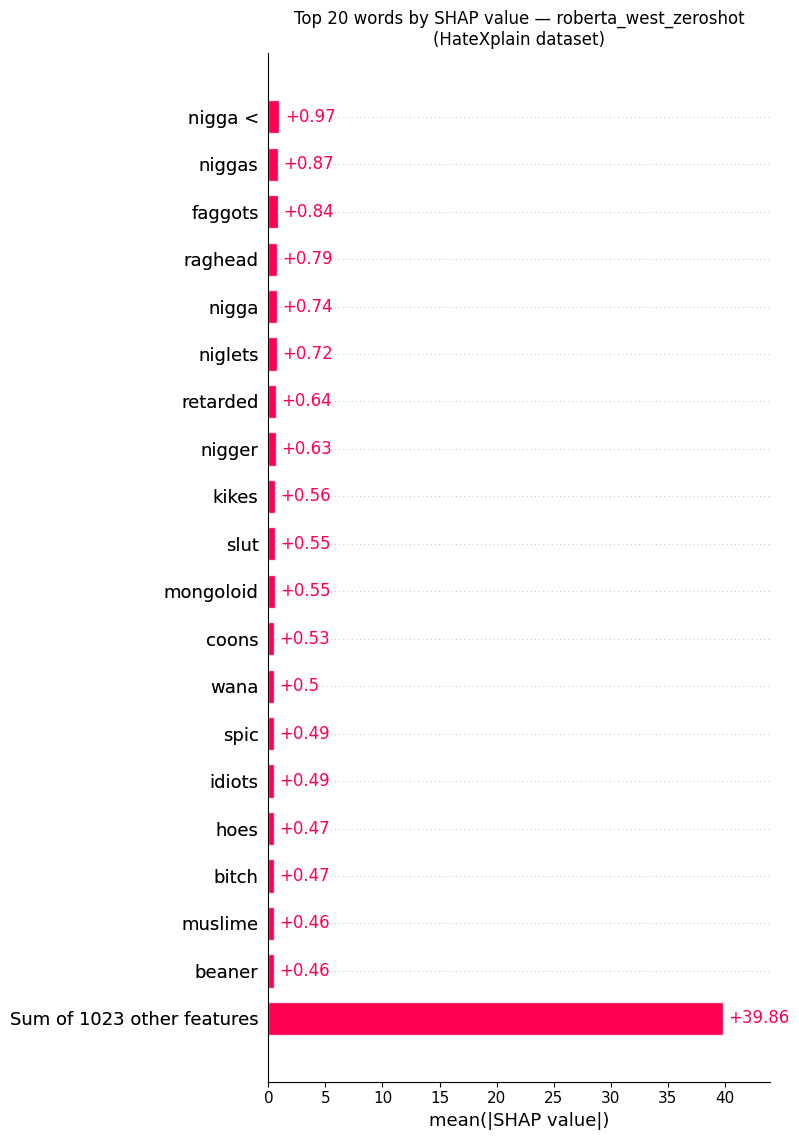

Saved shap_west_zs.png


In [ ]:
def make_shap_predictor(pipe):
    def shap_pred(texts):
        results = pipe(list(texts), truncation=True)
        return np.array([
            r['score'] if r['label'] == 'hate' else 1 - r['score']
            for r in results
        ])
    return shap_pred

def run_shap(pipe, df, n_samples=100, label='zeroshot', save_prefix='west_zs'):
    print(f'Computing SHAP on {n_samples} samples (~6-8 mins)...')
    sample_texts = df.sample(n=n_samples, random_state=SEED)['text'].tolist()
    shap_pred_fn = make_shap_predictor(pipe)
    masker       = shap.maskers.Text(r'\W+')
    explainer    = shap.Explainer(shap_pred_fn, masker)
    shap_values  = explainer(sample_texts, batch_size=16)
    shap.plots.bar(shap_values, max_display=20, show=False)
    plt.title(f'Top 20 words by SHAP value — {label}\n(HateXplain dataset)', fontsize=12)
    plt.tight_layout()
    fname = f'shap_{save_prefix}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')
    return shap_values

shap_zs = run_shap(zeroshot_pipe, df_te_zs, label='roberta_west_zeroshot', save_prefix='west_zs')


Demographic Bias — roberta_west_zeroshot
    Group  Samples  True Hate  Pred Hate  Hate Recall %
     Race     1374        595       1059           97.3
 Religion      834        378        630           95.8
   Gender      816        202        624           96.0
Ethnicity      494         91        267           91.2


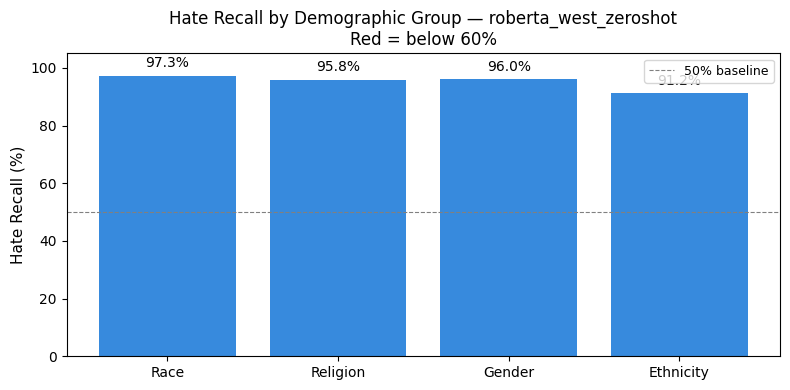

Saved demographic_west_zs.png
Log saved to results_log_west.json


In [ ]:
DEMOGRAPHIC_KEYWORDS = {
    'Race':      ['nigger','negro','nigga','niggas','coon','chink',
                  'spic','wetback','cracker','honky','black','white'],
    'Religion':  ['muslim','islam','jewish','jew','jews','allah',
                  'christian','kafir','mosque','kike'],
    'Gender':    ['woman','women','girl','female','bitch',
                  'whore','cunt','dyke','slut'],
    'Ethnicity': ['mexican','hispanic','asian','arab','immigrant',
                  'refugee','foreign','illegal'],
}

def demographic_bias_analysis(df, exp_name, save_prefix):
    rows = []
    for group, keywords in DEMOGRAPHIC_KEYWORDS.items():
        mask   = df['text'].str.lower().apply(
            lambda t: any(kw in str(t).lower() for kw in keywords)
        )
        subset = df[mask]
        if len(subset) == 0: continue
        true_hate = int(subset['hate_label'].sum())
        if true_hate == 0: continue
        hate_recall = round(
            subset[subset['hate_label']==1]['pred_label'].mean() * 100, 1
        )
        rows.append({'Group': group, 'Samples': len(subset),
            'True Hate': true_hate, 'Pred Hate': int(subset['pred_label'].sum()),
            'Hate Recall %': hate_recall})
    bias_df = pd.DataFrame(rows)
    print(f'\nDemographic Bias — {exp_name}')
    print(bias_df.to_string(index=False))
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['#E24B4A' if r < 60 else '#378ADD' for r in bias_df['Hate Recall %']]
    bars   = ax.bar(bias_df['Group'], bias_df['Hate Recall %'], color=colors)
    ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='50% baseline')
    ax.set_ylabel('Hate Recall (%)', fontsize=11); ax.set_ylim(0, 105)
    ax.set_title(f'Hate Recall by Demographic Group — {exp_name}\nRed = below 60%', fontsize=12)
    ax.legend(fontsize=9); plt.tight_layout()
    fname = f'demographic_{save_prefix}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print(f'Saved {fname}')
    results_log['experiments'][exp_name]['demographic_bias'] = bias_df.to_dict(orient='records')
    save_log()
    return bias_df

bias_zs = demographic_bias_analysis(df_te_zs, 'roberta_west_zeroshot', 'west_zs')

In [ ]:
SWAP_PAIRS = [
    ('muslim','christian'), ('jewish','christian'),
    ('black','white'),      ('woman','man'),
]

def perturbation_test(pipe, df, exp_name, n=15):
    pattern    = '|'.join([s for s, _ in SWAP_PAIRS])
    candidates = df[df['text'].str.lower().str.contains(pattern, na=False)].head(n)
    records = []
    print(f'\nPerturbation Test — {exp_name}')
    print(f'{"Text[:55]":<57} | Orig | Swap | Flipped?')
    print('-' * 85)
    for _, row in candidates.iterrows():
        orig = row['text']; swapped = orig
        for src, tgt in SWAP_PAIRS:
            swapped = re.sub(rf'\b{src}\b', tgt, swapped, flags=re.IGNORECASE)
        if swapped == orig: continue
        r_orig = pipe([orig], truncation=True)[0]
        r_swap = pipe([swapped], truncation=True)[0]
        s_orig = r_orig['score'] if r_orig['label']=='hate' else 1-r_orig['score']
        s_swap = r_swap['score'] if r_swap['label']=='hate' else 1-r_swap['score']
        flipped = abs(s_orig - s_swap) > 0.2
        print(f'{orig[:55]:<57} | {s_orig:.2f} | {s_swap:.2f} | {"YES" if flipped else "no"}')
        records.append({'text': orig[:80], 'orig_hate_score': round(s_orig,4),
            'swap_hate_score': round(s_swap,4), 'flipped': flipped})
    flipped_count = sum(r['flipped'] for r in records)
    print(f'\nFlipped: {flipped_count}/{len(records)} changed by >0.2 after demographic swap')
    results_log['experiments'][exp_name]['perturbation'] = {
        'total_tested': len(records), 'flipped': flipped_count, 'details': records}
    save_log()

perturbation_test(zeroshot_pipe, df_te_zs, 'roberta_west_zeroshot')


Perturbation Test — roberta_west_zeroshot
Text[:55]                                                 | Orig | Swap | Flipped?
-------------------------------------------------------------------------------------
fact check the muslim brotherhood are designated a terr   | 0.94 | 0.27 | YES
<user> if india can not accept muslim refugees then it    | 0.01 | 0.01 | no
according to <user> a man who masturbated in front of w   | 0.41 | 0.41 | no
well ya can not take the nigger out of the nigger but y   | 1.00 | 1.00 | no
no one is asking for an all white world either <number>   | 0.98 | 0.97 | no
how is all that awesome muslim diversity going for you    | 1.00 | 0.12 | YES
<number> black people placed in world strongest man in    | 0.65 | 0.38 | YES
so when are you and cyph going to move to africa to mak   | 0.93 | 0.92 | no
<user> both my ashkenazi parents took dna tests and it    | 0.07 | 0.06 | no
the handmaid tale is a jewish litmus test to see how re   | 0.99 | 0.99 | no
islam is a deat

In [ ]:
torch.save(zeroshot_pipe.model.state_dict(), 'roberta_west_zeroshot.pth')
print('Saved roberta_west_zeroshot.pth')

Saved roberta_west_zeroshot.pth


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_df(df):
    ds = Dataset.from_pandas(
        df[['text','hate_label']]
        .rename(columns={'hate_label':'label'})
        .reset_index(drop=True)
    )
    def tok(batch):
        return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)
    ds = ds.map(tok, batched=True)
    ds.set_format('torch', columns=['input_ids','attention_mask','label'])
    return ds

train_ds = tokenize_df(df_tr)
val_ds   = tokenize_df(df_val)
test_ds  = tokenize_df(df_te)
print(f'Tokenized — Train:{len(train_ds)} Val:{len(val_ds)} Test:{len(test_ds)}')

Map:   0%|          | 0/14103 [00:00<?, ? examples/s]

Map:   0%|          | 0/2015 [00:00<?, ? examples/s]

Map:   0%|          | 0/4030 [00:00<?, ? examples/s]

Tokenized — Train:14103 Val:2015 Test:4030


In [ ]:
label_counts  = df_tr['hate_label'].value_counts().sort_index()
class_weights = torch.tensor(
    [len(df_tr) / (2 * c) for c in label_counts], dtype=torch.float
)
print(f'Class weights: Not Hate={class_weights[0]:.3f}  Hate={class_weights[1]:.3f}')

ft_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':    round(accuracy_score(labels, preds), 4),
        'f1_macro':    round(f1_score(labels, preds, average='macro'), 4),
        'hate_recall': round(recall_score(labels, preds, pos_label=1), 4),
    }

training_args = TrainingArguments(
    output_dir='./ft_west_checkpoints', num_train_epochs=3,
    per_device_train_batch_size=32, per_device_eval_batch_size=64,
    learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.1,
    eval_strategy='epoch', save_strategy='epoch',
    load_best_model_at_end=True, metric_for_best_model='f1_macro',
    greater_is_better=True, fp16=True, dataloader_num_workers=2,
    logging_steps=50, report_to='none', push_to_hub=False,
)

trainer = WeightedTrainer(
    model=ft_model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
print('Trainer ready!')

Class weights: Not Hate=0.709  Hate=1.698


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: facebook/roberta-hate-speech-dynabench-r4-target
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready!


In [ ]:
print('Starting finetuning (~20-25 mins on T4 x2, larger dataset)...')
train_result = trainer.train()
print('\nFinetuning complete!')
print(train_result.metrics)

Starting finetuning (~20-25 mins on T4 x2, larger dataset)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Hate Recall
1,0.378997,0.407844,0.788100,0.774900,0.925900
2,0.328306,0.369526,0.838200,0.820100,0.883800
3,0.295524,0.389842,0.844200,0.825000,0.870400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Finetuning complete!
{'train_runtime': 535.3805, 'train_samples_per_second': 79.026, 'train_steps_per_second': 1.238, 'total_flos': 2782991410306560.0, 'train_loss': 0.37929517579114636, 'epoch': 3.0}


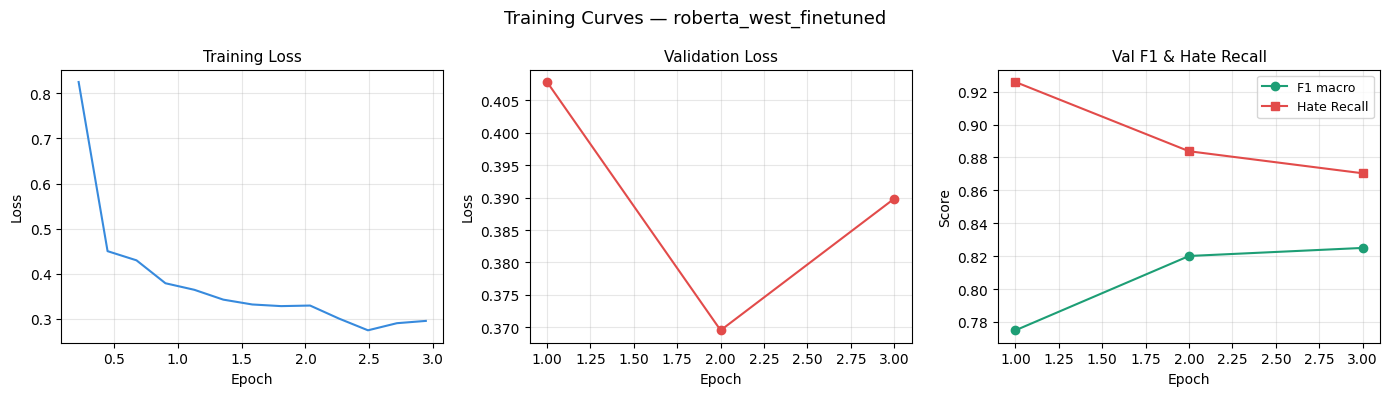

Saved training_curves_west.png
Log saved to results_log_west.json


In [ ]:
log_history  = trainer.state.log_history
train_losses = [(e['epoch'], e['loss']) for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_metrics = [(e['epoch'], e['eval_loss'], e.get('eval_f1_macro',0), e.get('eval_hate_recall',0))
                for e in log_history if 'eval_loss' in e]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
te, tl = zip(*train_losses)
axes[0].plot(te, tl, color='#378ADD')
axes[0].set_title('Training Loss', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
ee, el, ef, er = zip(*eval_metrics)
axes[1].plot(ee, el, color='#E24B4A', marker='o')
axes[1].set_title('Validation Loss', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].grid(alpha=0.3)
axes[2].plot(ee, ef, color='#1D9E75', marker='o', label='F1 macro')
axes[2].plot(ee, er, color='#E24B4A', marker='s', label='Hate Recall')
axes[2].set_title('Val F1 & Hate Recall', fontsize=11)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)
plt.suptitle('Training Curves — roberta_west_finetuned', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves_west.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved training_curves_west.png')
results_log['experiments']['roberta_west_finetuned'] = {
    'train_metrics': train_result.metrics,
    'training_curves': {
        'train_loss': list(zip([round(e,2) for e in te],[round(l,4) for l in tl])),
        'eval_loss':  list(zip([round(e,2) for e in ee],[round(l,4) for l in el])),
        'eval_f1':    list(zip([round(e,2) for e in ee],[round(f,4) for f in ef])),
    }
}
save_log()

In [ ]:
ft_preds_raw = trainer.predict(test_ds)
ft_preds     = np.argmax(ft_preds_raw.predictions, axis=-1)
y_true_test  = df_te['hate_label'].tolist()
df_te_ft = df_te.copy()
df_te_ft['pred_label'] = ft_preds
ft_metrics = log_metrics(y_true_test, ft_preds, 'roberta_west_finetuned')


===== roberta_west_finetuned | test =====
Accuracy      : 84.14%
F1 (macro)    : 82.18%
Hate Recall   : 86.52%
Hate Precision: 68.19%

Full Report:
              precision    recall  f1-score   support

    Not Hate       0.94      0.83      0.88      2843
        Hate       0.68      0.87      0.76      1187

    accuracy                           0.84      4030
   macro avg       0.81      0.85      0.82      4030
weighted avg       0.86      0.84      0.85      4030

Log saved to results_log_west.json


Running LIME on roberta_west_finetuned (50 samples, ~4 mins)...
  LIME 0/50...
  LIME 10/50...
  LIME 20/50...
  LIME 30/50...
  LIME 40/50...


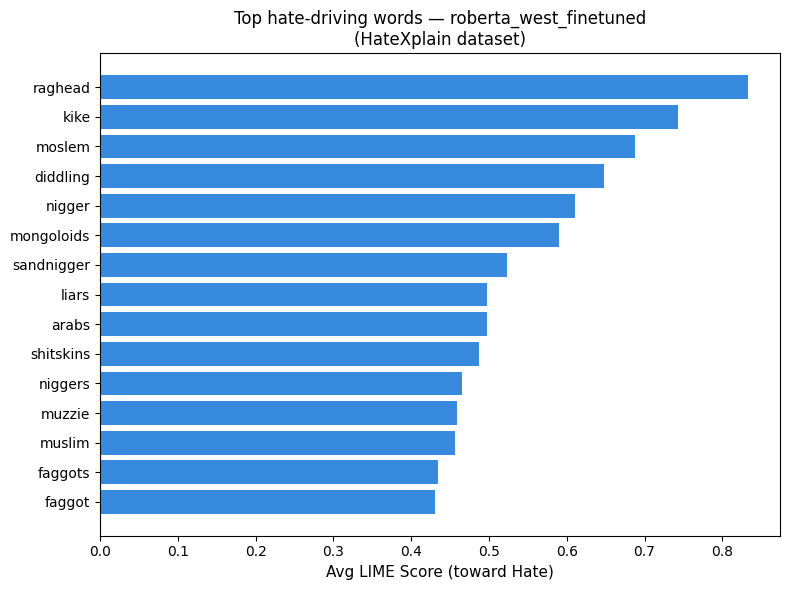

Saved lime_west_ft.png
Log saved to results_log_west.json


In [ ]:
ft_pipe = pipeline(
    'text-classification',
    model=trainer.model, tokenizer=tokenizer,
    device=DEVICE, batch_size=64
)
print('Running LIME on roberta_west_finetuned (50 samples, ~4 mins)...')
ft_predictor = make_predictor(ft_pipe)
lime_ft = run_lime(ft_predictor, df_te_ft, label='roberta_west_finetuned', save_prefix='west_ft')

Computing SHAP on 100 samples (~6-8 mins)...


PartitionExplainer explainer: 101it [01:26,  1.01it/s]                         


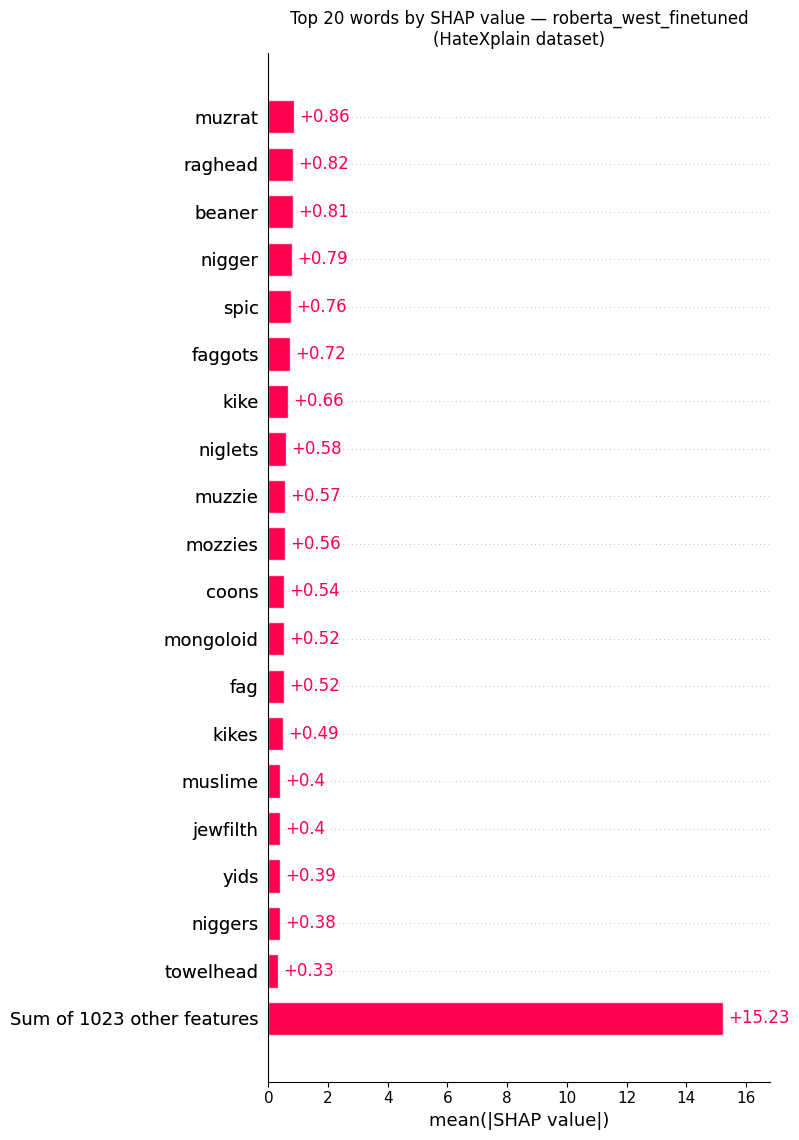

Saved shap_west_ft.png


In [ ]:
shap_ft = run_shap(ft_pipe, df_te_ft, label='roberta_west_finetuned', save_prefix='west_ft')


Demographic Bias — roberta_west_finetuned
    Group  Samples  True Hate  Pred Hate  Hate Recall %
     Race     1374        595        726           91.8
 Religion      834        378        485           90.2
   Gender      816        202        251           82.2
Ethnicity      494         91        139           76.9


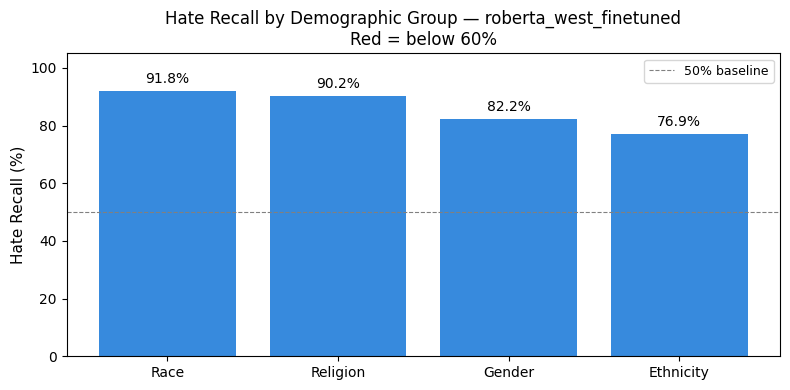

Saved demographic_west_ft.png
Log saved to results_log_west.json


In [ ]:
bias_ft = demographic_bias_analysis(df_te_ft, 'roberta_west_finetuned', 'west_ft')

In [ ]:
perturbation_test(ft_pipe, df_te_ft, 'roberta_west_finetuned')


Perturbation Test — roberta_west_finetuned
Text[:55]                                                 | Orig | Swap | Flipped?
-------------------------------------------------------------------------------------
fact check the muslim brotherhood are designated a terr   | 0.12 | 0.01 | no
<user> if india can not accept muslim refugees then it    | 0.00 | 0.00 | no
according to <user> a man who masturbated in front of w   | 0.03 | 0.03 | no
well ya can not take the nigger out of the nigger but y   | 0.98 | 0.98 | no
no one is asking for an all white world either <number>   | 0.94 | 0.93 | no
how is all that awesome muslim diversity going for you    | 0.01 | 0.01 | no
<number> black people placed in world strongest man in    | 0.37 | 0.34 | no
so when are you and cyph going to move to africa to mak   | 0.76 | 0.77 | no
<user> both my ashkenazi parents took dna tests and it    | 0.01 | 0.01 | no
the handmaid tale is a jewish litmus test to see how re   | 0.05 | 0.02 | no
islam is a death 

In [ ]:
torch.save(trainer.model.state_dict(), 'roberta_west_finetuned.pth')
print('Saved roberta_west_finetuned.pth')

Saved roberta_west_finetuned.pth


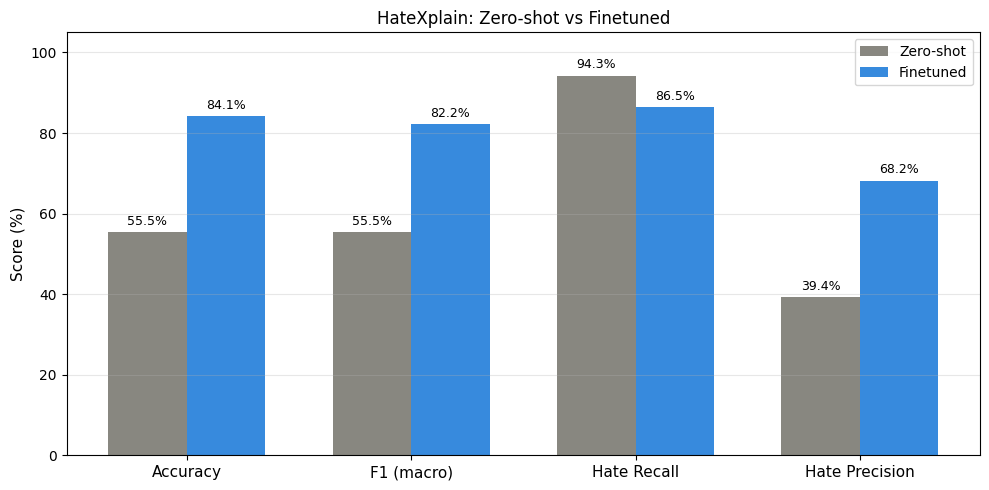

Saved comparison_west.png


In [ ]:
exp         = results_log['experiments']
models      = ['roberta_west_zeroshot','roberta_west_finetuned']
labels      = ['Zero-shot','Finetuned']
metric_keys = ['accuracy','f1_macro','hate_recall','hate_precision']
mlabels     = ['Accuracy','F1 (macro)','Hate Recall','Hate Precision']
colors      = ['#888780','#378ADD']
x = np.arange(len(metric_keys)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, lbl, c) in enumerate(zip(models, labels, colors)):
    vals = [exp[m]['test'][k]*100 for k in metric_keys]
    bars = ax.bar(x + (i-0.5)*w, vals, w, label=lbl, color=c)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(mlabels, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11); ax.set_ylim(0, 105)
ax.set_title('HateXplain: Zero-shot vs Finetuned', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_west.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved comparison_west.png')

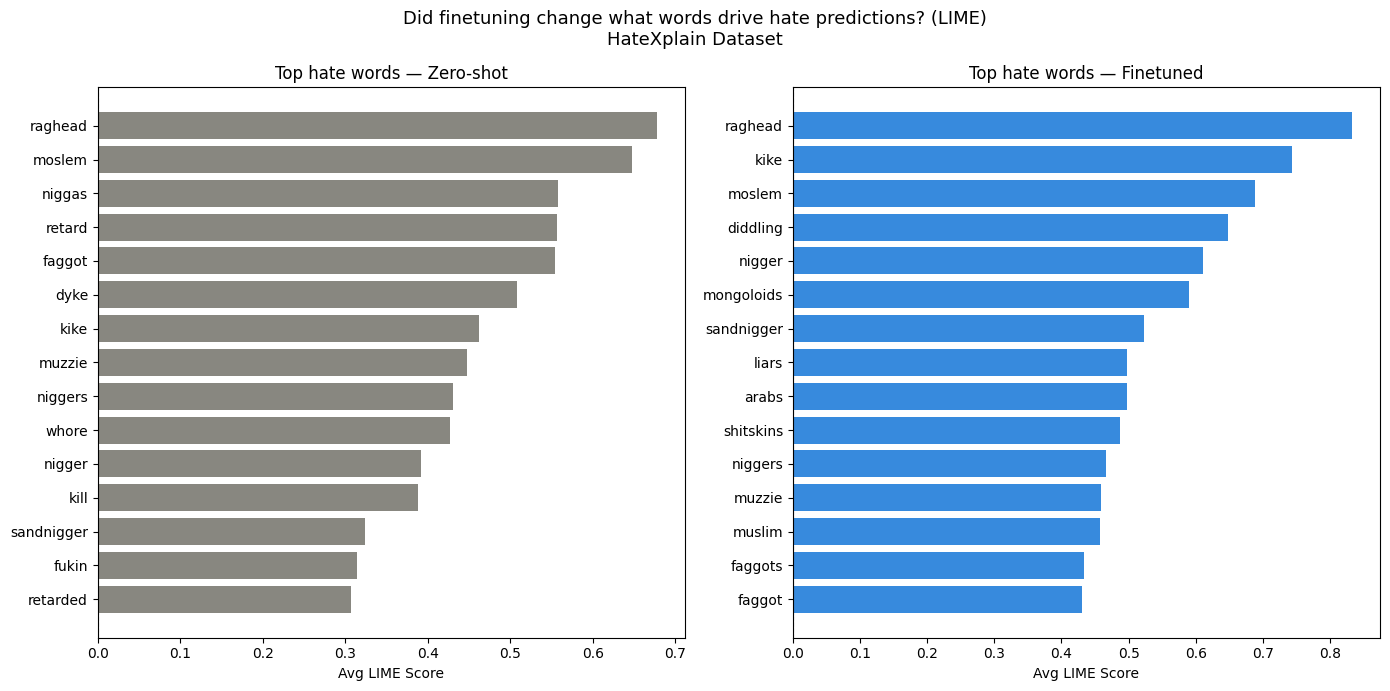

Saved lime_comparison_west.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
top_zs = lime_zs.head(15).sort_values('avg_lime_score')
ax1.barh(top_zs['word'], top_zs['avg_lime_score'], color='#888780')
ax1.set_title('Top hate words — Zero-shot', fontsize=12)
ax1.set_xlabel('Avg LIME Score'); ax1.axvline(0, color='gray', linewidth=0.8, linestyle='--')
top_ft = lime_ft.head(15).sort_values('avg_lime_score')
ax2.barh(top_ft['word'], top_ft['avg_lime_score'], color='#378ADD')
ax2.set_title('Top hate words — Finetuned', fontsize=12)
ax2.set_xlabel('Avg LIME Score'); ax2.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.suptitle('Did finetuning change what words drive hate predictions? (LIME)\nHateXplain Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('lime_comparison_west.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved lime_comparison_west.png')

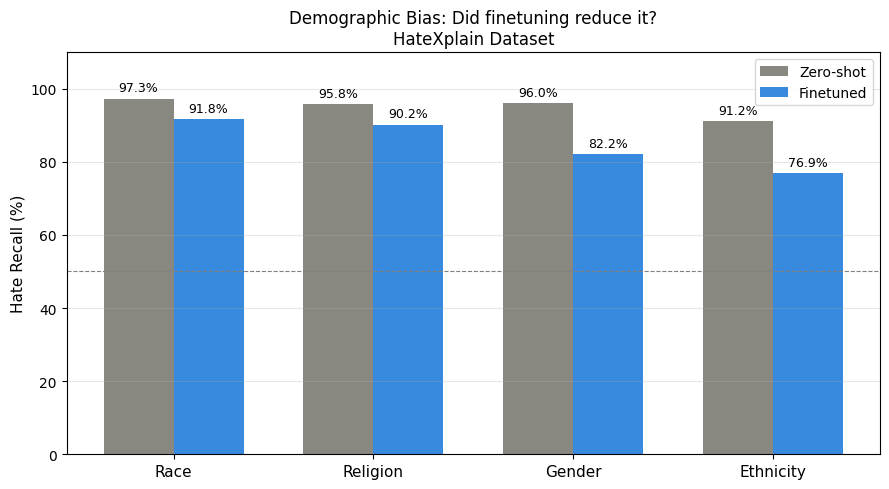

Saved demographic_comparison_west.png


In [ ]:
bias_zs_r = bias_zs.set_index('Group')['Hate Recall %']
bias_ft_r = bias_ft.set_index('Group')['Hate Recall %']
groups = bias_zs_r.index.tolist()
x = np.arange(len(groups)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, bias_zs_r.values, w, label='Zero-shot', color='#888780')
b2 = ax.bar(x + w/2, bias_ft_r.reindex(groups).values, w, label='Finetuned', color='#378ADD')
ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel('Hate Recall (%)', fontsize=11); ax.set_ylim(0, 110)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Demographic Bias: Did finetuning reduce it?\nHateXplain Dataset', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('demographic_comparison_west.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved demographic_comparison_west.png')

In [ ]:
save_log()
print('\n===== FINAL RESULTS SUMMARY =====')
for exp_name, exp_data in results_log['experiments'].items():
    if 'test' in exp_data:
        t = exp_data['test']
        print(f'\n{exp_name}')
        print(f'  Accuracy      : {t["accuracy"]*100:.2f}%')
        print(f'  F1 (macro)    : {t["f1_macro"]*100:.2f}%')
        print(f'  Hate Recall   : {t["hate_recall"]*100:.2f}%')
        print(f'  Hate Precision: {t["hate_precision"]*100:.2f}%')
print('\nAll outputs saved:')
print('  results_log_west.json')
print('  roberta_west_zeroshot.pth | roberta_west_finetuned.pth')
print('  lime_west_zs.png | lime_west_ft.png | lime_comparison_west.png')
print('  shap_west_zs.png | shap_west_ft.png')
print('  demographic_west_zs.png | demographic_west_ft.png | demographic_comparison_west.png')
print('  training_curves_west.png | comparison_west.png')

Log saved to results_log_west.json

===== FINAL RESULTS SUMMARY =====

roberta_west_zeroshot
  Accuracy      : 55.51%
  F1 (macro)    : 55.51%
  Hate Recall   : 94.27%
  Hate Precision: 39.35%

roberta_west_finetuned
  Accuracy      : 84.14%
  F1 (macro)    : 82.18%
  Hate Recall   : 86.52%
  Hate Precision: 68.19%

All outputs saved:
  results_log_west.json
  roberta_west_zeroshot.pth | roberta_west_finetuned.pth
  lime_west_zs.png | lime_west_ft.png | lime_comparison_west.png
  shap_west_zs.png | shap_west_ft.png
  demographic_west_zs.png | demographic_west_ft.png | demographic_comparison_west.png
  training_curves_west.png | comparison_west.png
